# Stochastic Subgradient Descent, with and without Momentum

**Course project — Advanced Optimization Methods for Machine Learning**

We implement stochastic subgradient descent (SSGD) and SSGD with heavy-ball momentum, and apply
them to two deliberately **non-smooth** problems:

| Problem | Where the non-smoothness lives |
|---|---|
| LASSO regression | the $\ell_1$ penalty $\lambda\lVert w\rVert_1$, non-differentiable at $w_i = 0$ |
| Multi-layer ReLU network | the ReLU kink at $0$ |

Each is studied on **synthetic data with a known ground truth** (so correctness is checkable
rather than merely plausible) and then on **real data** (California housing, MNIST).

### The central subtlety

The subgradient method is **not a descent method**. For a subgradient $g_k \in \partial f(w_k)$,
$f(w_{k+1})$ may be *larger* than $f(w_k)$ — no matter how small the step. The convergence theory
is therefore stated for the **running best iterate** $\min_{j\le k} f(w_j)$ or the **averaged
iterate**, never for $f(w_k)$ itself. Everything below tracks all three, and §3 shows the raw
iterate visibly rising.

### Method

$$\text{SSGD:}\quad w_{k+1} = w_k - \alpha_k\, g_k, \qquad g_k \in \partial f_{i_k}(w_k)$$

$$\text{Momentum:}\quad v_{k+1} = \beta v_k + g_k, \qquad w_{k+1} = w_k - \alpha_k v_{k+1}$$

with step sizes $\alpha_k = \alpha_0$ (constant), $\alpha_0/\sqrt{k+1}$, or $\alpha_0/(k+1)$.
For non-smooth convex problems a constant step converges only to a *neighbourhood* of the optimum;
genuine convergence needs $\alpha_k \to 0$ with $\sum_k \alpha_k = \infty$. §4 demonstrates this
directly.

The implementation lives in `src/aomml/` and is covered by 55 tests (`uv run pytest`); this
notebook is the experimental narrative on top of it.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
import numpy as np
import torch
from sklearn.linear_model import Lasso

from aomml.data import load_california_housing, load_mnist, make_sparse_regression
from aomml.models import LinearModel, ReLUMLP
from aomml.objectives import analytic_lasso_subgradient, is_valid_subgradient, lasso_objective
from aomml.optimizers import SSGD, SSGDMomentum
from aomml.train import evaluate_accuracy, train
from aomml.utils import Standardizer, get_device, seed_everything

seed_everything(42)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3,
                     "figure.figsize": (11, 4), "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 10})

# float64 on CPU for LASSO (tight comparison against scikit-learn);
# float32 on MPS for MNIST. MPS has no float64 kernels, so this is not optional.
print("LASSO device:", get_device(dtype=torch.float64), "| MNIST device:", get_device(dtype=torch.float32))

LASSO device: cpu | MNIST device: mps


---
## 1. The objective and its subgradient

$$f(w, b) = \frac{1}{2n}\lVert Xw + b\mathbf{1} - y\rVert_2^2 + \lambda\lVert w\rVert_1$$

The intercept $b$ is **not** penalised — penalising it would force the response's mean into the
shrunk coefficients and bias the whole solution toward zero.

Before optimising anything, we check the gradient machinery is right. Two things must hold:

1. At a **smooth** point, autograd must agree with the closed form
   $\nabla f = \tfrac{1}{n}X^\top(Xw + b - y) + \lambda\,\mathrm{sign}(w)$.
2. At $w = 0$ the objective is **non-smooth**, and any $g$ with
   $\lvert g_i - [\tfrac1n X^\top(Xw-y)]_i\rvert \le \lambda$ is a legitimate subgradient.
   PyTorch returns $\mathrm{sign}(0) = 0$, which is a valid selection — we verify rather than assume.

In [2]:
data = make_sparse_regression(n=200, d=50, k=5, noise_std=0.1, seed=42)
lam = 0.02
print(f"synthetic problem: X {tuple(data.X.shape)}, {data.support.numel()} true non-zeros "
      f"at indices {data.support.tolist()}")

# (1) smooth point: autograd vs closed form
w = torch.randn(50, dtype=torch.float64, requires_grad=True)
b = torch.tensor(0.3, dtype=torch.float64, requires_grad=True)
g_w, g_b = torch.autograd.grad(lasso_objective(w, data.X, data.y, lam, b), [w, b])
a_w, a_b = analytic_lasso_subgradient(w.detach(), data.X, data.y, lam, b.detach())
print(f"max |autograd - analytic|  = {(g_w - a_w).abs().max():.2e}   (weights)")
print(f"    |autograd - analytic|  = {(g_b - a_b).abs():.2e}   (intercept)")

# (2) non-smooth point w = 0
w0 = torch.zeros(50, dtype=torch.float64, requires_grad=True)
g0, = torch.autograd.grad(lasso_objective(w0, data.X, data.y, lam), [w0])
valid = is_valid_subgradient(g0, w0.detach(), data.X, data.y, lam)
print(f"at w = 0: all {valid.numel()} coordinates a valid subgradient? {bool(valid.all())}")

synthetic problem: X (200, 50), 5 true non-zeros at indices [5, 10, 24, 28, 44]
max |autograd - analytic|  = 4.44e-16   (weights)
    |autograd - analytic|  = 1.11e-16   (intercept)
at w = 0: all 50 coordinates a valid subgradient? True


---
## 2. E1 — SSGD vs momentum on synthetic LASSO

Both methods are run against the same problem and compared to the optimum found by
**scikit-learn's coordinate descent**, an entirely independent solver. Agreement with an external
reference is the strongest available evidence that the objective, the optimizer and the training
loop are jointly correct.

We plot the **optimality gap** $f(w_k^{\text{best}}) - f^\star$ on log axes.

scikit-learn optimum  f* = 0.1499426123   (6 non-zeros)


SSGD             f_best - f* = 7.408e-05   max|w - w_sklearn| = 0.00148
SSGD + momentum  f_best - f* = 6.011e-05   max|w - w_sklearn| = 0.00140


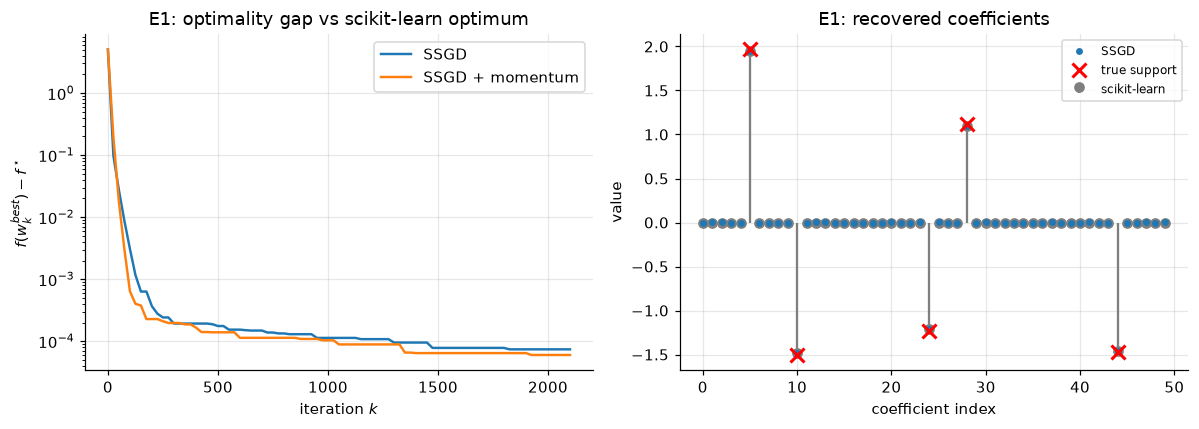

In [3]:
loss = lambda m, Xb, yb: lasso_objective(m.weight, Xb, yb, lam, m.bias)

sk = Lasso(alpha=lam, fit_intercept=True, max_iter=200_000, tol=1e-14).fit(data.X.numpy(), data.y.numpy())
w_star = torch.tensor(sk.coef_, dtype=torch.float64)
f_star = float(lasso_objective(w_star, data.X, data.y, lam, torch.tensor(sk.intercept_)))
print(f"scikit-learn optimum  f* = {f_star:.10f}   ({int((w_star.abs() > 1e-8).sum())} non-zeros)")

runs = {}
for label, make_opt in [
    ("SSGD",           lambda p: SSGD(p, lr=0.3, schedule="inv_sqrt")),
    ("SSGD + momentum", lambda p: SSGDMomentum(p, lr=0.05, beta=0.9, schedule="inv_sqrt")),
]:
    model = LinearModel(50)
    runs[label] = (train(model, loss, data.X, data.y, make_opt(model.parameters()),
                         epochs=300, batch_size=32, eval_every=25, seed=0), model)

fig, (ax1, ax2) = plt.subplots(1, 2)
for label, (h, model) in runs.items():
    ax1.semilogy(h.step, np.array(h.f_best) - f_star, label=label, lw=1.6)
    err = (model.weight.detach() - w_star).abs().max()
    print(f"{label:<16} f_best - f* = {h.final_best - f_star:.3e}   max|w - w_sklearn| = {err:.5f}")
ax1.set(xlabel="iteration $k$", ylabel=r"$f(w_k^{best}) - f^\star$",
        title="E1: optimality gap vs scikit-learn optimum")
ax1.legend()

ax2.stem(np.arange(50), w_star.numpy(), linefmt="C7-", markerfmt="C7o", basefmt=" ", label="scikit-learn")
ax2.plot(np.arange(50), runs["SSGD"][1].weight.detach().numpy(), "C0.", ms=7, label="SSGD")
ax2.plot(data.support.numpy(), data.w_true[data.support].numpy(), "rx", ms=9, mew=2, label="true support")
ax2.set(xlabel="coefficient index", ylabel="value", title="E1: recovered coefficients")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 3. E2 — the subgradient method is not a descent method

This is the point most easily mistaken for a bug. Below, the **raw iterate** $f(w_k)$ is plotted
against the **running best** $\min_{j\le k} f(w_j)$ and the **Polyak-averaged** iterate.

$f(w_k)$ oscillates and rises repeatedly. That is not instability and not a defect — it is what
the subgradient method does. A subgradient is not a descent direction at a non-smooth point, and
with stochastic sampling each step follows only one $f_{i_k}$. Only the lower envelope and the
average are guaranteed to improve.

f(w_k) increased on 61 of 140 recorded steps (44%) — yet the method still converges.


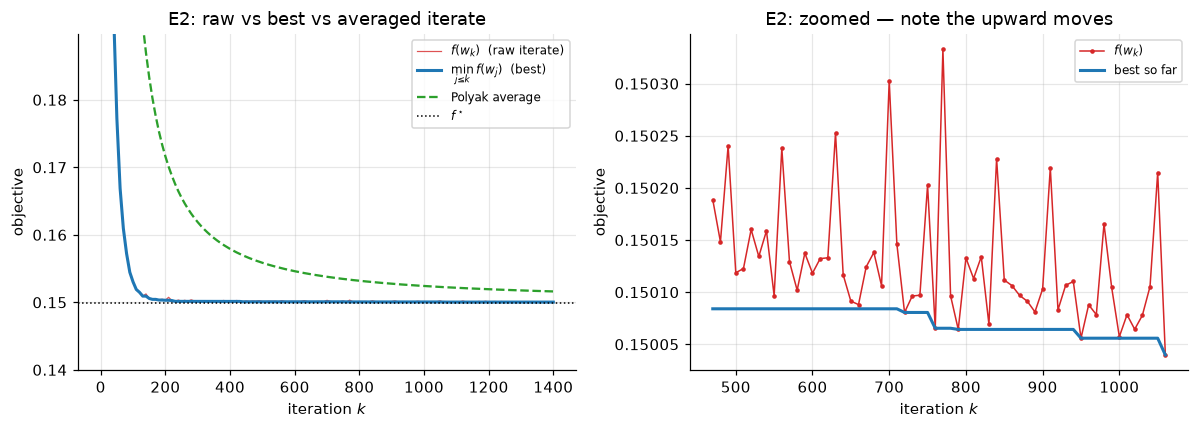

In [4]:
model = LinearModel(50)
h = train(model, loss, data.X, data.y, SSGD(model.parameters(), lr=0.3, schedule="inv_sqrt"),
          epochs=200, batch_size=32, eval_every=10, seed=0)

rises = sum(1 for a, b in zip(h.f, h.f[1:]) if b > a)
print(f"f(w_k) increased on {rises} of {len(h.f) - 1} recorded steps "
      f"({100 * rises / (len(h.f) - 1):.0f}%) — yet the method still converges.")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.plot(h.step, h.f, color="C3", lw=0.8, alpha=0.8, label=r"$f(w_k)$  (raw iterate)")
ax1.plot(h.step, h.f_best, color="C0", lw=2, label=r"$\min_{j\leq k} f(w_j)$  (best)")
ax1.plot(h.step, h.f_avg, color="C2", lw=1.5, ls="--", label="Polyak average")
ax1.axhline(f_star, color="k", ls=":", lw=1, label=r"$f^\star$")
ax1.set(xlabel="iteration $k$", ylabel="objective", title="E2: raw vs best vs averaged iterate",
        ylim=(f_star - 0.01, np.percentile(h.f, 97)))
ax1.legend(fontsize=8)

zoom = slice(len(h.step) // 3, len(h.step) // 3 + 60)
ax2.plot(np.array(h.step)[zoom], np.array(h.f)[zoom], "C3.-", lw=1, ms=4, label=r"$f(w_k)$")
ax2.plot(np.array(h.step)[zoom], np.array(h.f_best)[zoom], "C0-", lw=2, label="best so far")
ax2.set(xlabel="iteration $k$", ylabel="objective", title="E2: zoomed — note the upward moves")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

---
## 4. E3 — step size decides whether you converge at all

The theory: with a **constant** step $\alpha$, SSGD converges only to a neighbourhood of $f^\star$
whose radius scales with $\alpha$; it then hovers there forever. Convergence requires
$\alpha_k \to 0$ with $\sum_k \alpha_k = \infty$.

The test below makes this visible by **quadrupling the iteration budget**. If a schedule has
stalled in a noise ball, 4× the compute buys nothing.

schedule     gap @ 100 ep   gap @ 400 ep   improvement
------------------------------------------------------------


constant       5.4616e+00     5.4616e+00   STALLED — 4x compute gained nothing


inv_sqrt       2.4933e-03     6.6512e-04   3.7x better


inv            2.4959e-03     1.3612e-04   18.3x better


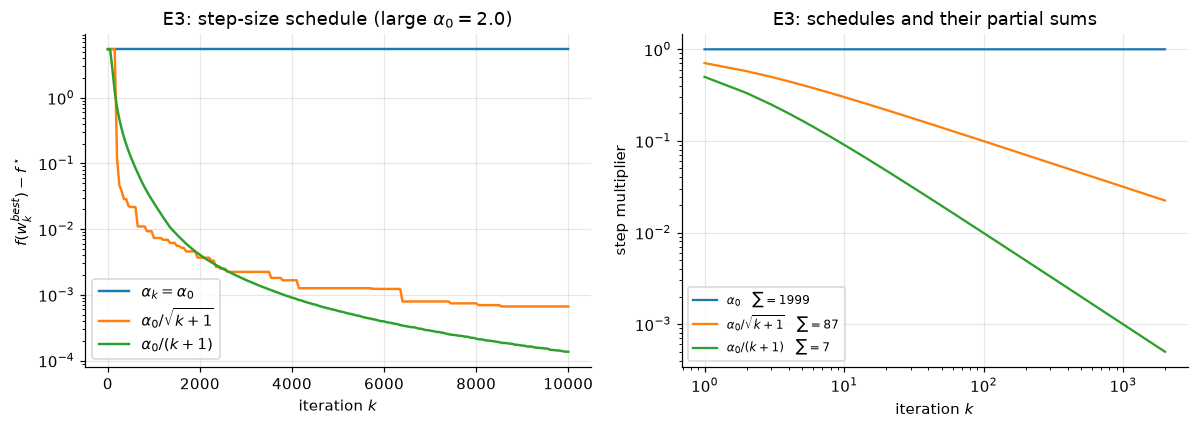

In [5]:
noisy = make_sparse_regression(n=200, d=40, k=5, noise_std=0.5, seed=3)
loss_n = lambda m, Xb, yb: lasso_objective(m.weight, Xb, yb, 0.02, m.bias)
sk_n = Lasso(alpha=0.02, fit_intercept=True, max_iter=200_000, tol=1e-14).fit(noisy.X.numpy(), noisy.y.numpy())
f_star_n = float(lasso_objective(torch.tensor(sk_n.coef_), noisy.X, noisy.y, 0.02,
                                 torch.tensor(sk_n.intercept_)))

plt.figure(figsize=(11, 4))
ax = plt.subplot(1, 2, 1)
print(f"{'schedule':<10} {'gap @ 100 ep':>14} {'gap @ 400 ep':>14}   improvement")
print("-" * 60)
for i, sched in enumerate(["constant", "inv_sqrt", "inv"]):
    gaps = {}
    for ep in (100, 400):
        m = LinearModel(40)
        hh = train(m, loss_n, noisy.X, noisy.y, SSGD(m.parameters(), lr=2.0, schedule=sched),
                   epochs=ep, batch_size=8, eval_every=50, seed=0)
        gaps[ep] = hh.final_best - f_star_n
        if ep == 400:
            ax.semilogy(hh.step, np.array(hh.f_best) - f_star_n, lw=1.6,
                        label={"constant": r"$\alpha_k=\alpha_0$", "inv_sqrt": r"$\alpha_0/\sqrt{k+1}$",
                               "inv": r"$\alpha_0/(k+1)$"}[sched], color=f"C{i}")
    ratio = gaps[100] / gaps[400]
    verdict = "STALLED — 4x compute gained nothing" if ratio < 1.05 else f"{ratio:.1f}x better"
    print(f"{sched:<10} {gaps[100]:>14.4e} {gaps[400]:>14.4e}   {verdict}")

ax.set(xlabel="iteration $k$", ylabel=r"$f(w_k^{best}) - f^\star$",
       title="E3: step-size schedule (large $\\alpha_0 = 2.0$)")
ax.legend()

ax2 = plt.subplot(1, 2, 2)
ks = np.arange(1, 2000)
for i, (lbl, f) in enumerate([(r"$\alpha_0$", np.ones_like(ks, dtype=float)),
                              (r"$\alpha_0/\sqrt{k+1}$", 1 / np.sqrt(ks + 1)),
                              (r"$\alpha_0/(k+1)$", 1 / (ks + 1))]):
    ax2.loglog(ks, f, label=f"{lbl}   $\\sum={np.sum(f):.0f}$", color=f"C{i}")
ax2.set(xlabel="iteration $k$", ylabel=r"step multiplier", title=r"E3: schedules and their partial sums")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

The constant step is fastest early — and then stops entirely, sitting in its noise ball while both
decaying schedules walk straight past it. Quadrupling its budget moved its gap by less than
$10^{-6}$ relative: it is not converging slowly, it has *stopped*.

Note that $\alpha_0/(k+1)$ came out **ahead** of $\alpha_0/\sqrt{k+1}$ here, which is worth being
precise about rather than glossing. With a large $\alpha_0 = 2.0$ and a noisy problem
($\sigma = 0.5$), the dominant error term is the variance of the stochastic subgradient, and the
faster-decaying schedule suppresses it sooner. The usual caution about $\alpha_0/(k+1)$ is a
different regime: its partial sums grow only logarithmically, so when the iterate starts far from
$w^\star$ the total distance it can travel is limited and it stalls short. That failure mode does
not bite here because $w_0 = 0$ is already close to a sparse solution.

$\alpha_0/\sqrt{k+1}$ remains our default because it is the schedule with the standard
$O(1/\sqrt{k})$ guarantee and it is far less sensitive to $\alpha_0$ — but "always decay faster"
would be the wrong lesson to take from this single plot.

---
## 5. E4 — momentum, and where it actually helps

Heavy-ball momentum earns its keep on **ill-conditioned** problems, where plain gradient steps
zig-zag across a narrow valley. We use the synthetic generator's `condition_number` control to
build a problem with $\kappa(X) = 200$ and compare $\beta \in \{0, 0.5, 0.9, 0.99\}$.

condition number of X: 200.0


beta = 0.0   final f_best = 2.292e-04


beta = 0.5   final f_best = 4.167e-05


beta = 0.9   final f_best = 4.407e-06


beta = 0.99  final f_best = 2.458e-13

momentum (beta=0.99) is 9.33e+08x closer to the optimum than plain SSGD


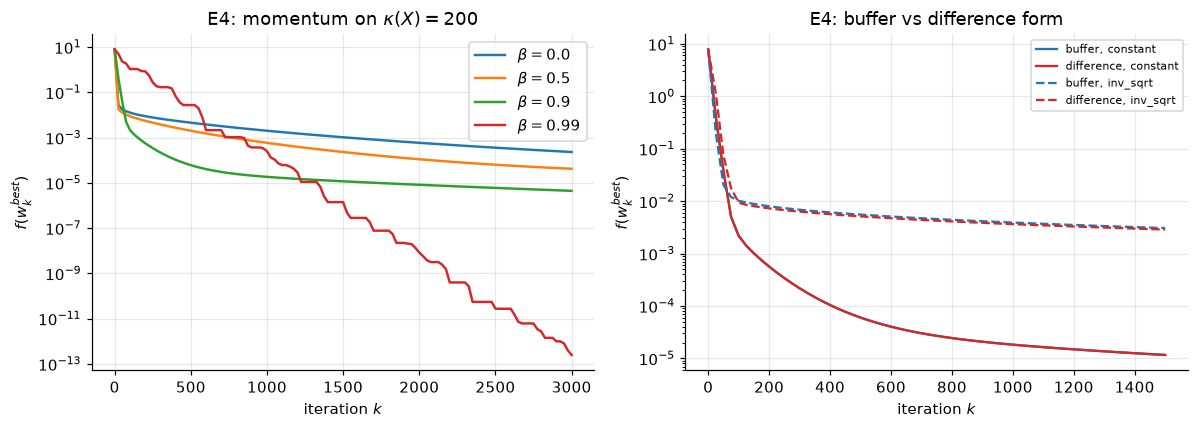

In [6]:
ill = make_sparse_regression(n=300, d=30, k=30, noise_std=0.0, condition_number=200.0, seed=11)
smooth_loss = lambda m, Xb, yb: lasso_objective(m.weight, Xb, yb, 0.0, m.bias)
print(f"condition number of X: {torch.linalg.cond(ill.X):.1f}")

plt.figure(figsize=(11, 4))
ax = plt.subplot(1, 2, 1)
finals = {}
for i, beta in enumerate([0.0, 0.5, 0.9, 0.99]):
    m = LinearModel(30)
    opt = (SSGD(m.parameters(), lr=1.0, schedule="constant") if beta == 0
           else SSGDMomentum(m.parameters(), lr=1.0, beta=beta, schedule="constant"))
    hh = train(m, smooth_loss, ill.X, ill.y, opt, epochs=3000, batch_size=300, eval_every=25, seed=0)
    finals[beta] = hh.final_best
    ax.semilogy(hh.step, hh.f_best, label=rf"$\beta = {beta}$", color=f"C{i}", lw=1.6)
    print(f"beta = {beta:<5} final f_best = {hh.final_best:.3e}")
print(f"\nmomentum (beta=0.99) is {finals[0.0] / finals[0.99]:.3g}x closer to the optimum than plain SSGD")
ax.set(xlabel="iteration $k$", ylabel=r"$f(w_k^{best})$", title=r"E4: momentum on $\kappa(X)=200$")
ax.legend()

# The two momentum formulations: identical at constant step, different when alpha decays.
ax2 = plt.subplot(1, 2, 2)
for sched, ls in [("constant", "-"), ("inv_sqrt", "--")]:
    for variant, c in [("buffer", "C0"), ("difference", "C3")]:
        m = LinearModel(30)
        hh = train(m, smooth_loss, ill.X, ill.y,
                   SSGDMomentum(m.parameters(), lr=1.0, beta=0.9, schedule=sched, variant=variant),
                   epochs=1500, batch_size=300, eval_every=25, seed=0)
        ax2.semilogy(hh.step, hh.f_best, ls, color=c, lw=1.5, label=f"{variant}, {sched}")
ax2.set(xlabel="iteration $k$", ylabel=r"$f(w_k^{best})$",
        title="E4: buffer vs difference form")
ax2.legend(fontsize=7)
plt.tight_layout(); plt.show()

The right-hand panel shows a subtlety worth stating precisely. The **buffer** form
$v \leftarrow \beta v + g,\; w \leftarrow w - \alpha_k v$ and Polyak's **difference** form
$w \leftarrow w - \alpha_k g + \beta(w_k - w_{k-1})$ are *algebraically identical* when $\alpha$ is
constant — telescoping gives $w_k - w_{k-1} = -\alpha v_k$, so the two solid curves coincide.

Once $\alpha_k$ decays they separate (dashed), because the buffer form rescales the entire
accumulated history by the *current* $\alpha_k$, while the difference form leaves the previous
displacement at the scale it was originally taken with. Since decaying steps are exactly what
non-smooth convergence requires, this distinction is live here rather than academic.

---
## 6. E5 — sparsity and the regularisation path

Sweeping $\lambda$ traces the trade-off between fit and sparsity.

One honest caveat, visible in the numbers below: **plain subgradient descent does not produce
exact zeros.** Coordinate descent and proximal methods (ISTA/FISTA) land coefficients exactly on
zero because they apply a soft-threshold; a subgradient step merely pushes toward zero and
overshoots past it. So the recovered support must be *thresholded*, and will generally be slightly
larger than the true one. This is a property of the method, not a defect in the implementation —
and it is a good argument for proximal methods when exact sparsity is the goal.

coefficients set *exactly* to zero by SSGD, across all 10 lambdas: 0 of 50   (scikit-learn, for comparison: up to 45)
true support recovered at 10/10 of the tested lambdas


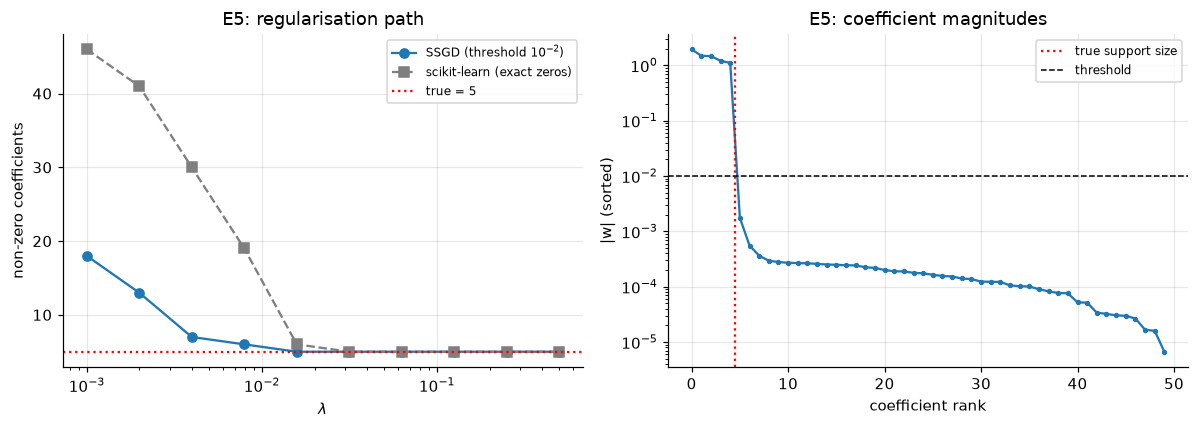

In [7]:
lams = np.logspace(-3, -0.3, 10)
nnz_ours, nnz_sk, recovered_all, exact_zeros = [], [], [], []
for lm in lams:
    m = LinearModel(50)
    train(m, lambda mm, Xb, yb: lasso_objective(mm.weight, Xb, yb, float(lm), mm.bias),
          data.X, data.y, SSGD(m.parameters(), lr=0.3, schedule="inv_sqrt"),
          epochs=200, batch_size=32, eval_every=200, seed=0)
    w_hat = m.weight.detach()
    nnz_ours.append(int((w_hat.abs() > 1e-2).sum()))
    exact_zeros.append(int((w_hat == 0).sum()))
    sk_i = Lasso(alpha=float(lm), fit_intercept=True, max_iter=100_000, tol=1e-12).fit(data.X.numpy(), data.y.numpy())
    nnz_sk.append(int((np.abs(sk_i.coef_) > 1e-8).sum()))
    recovered = set(torch.nonzero(w_hat.abs() > 1e-2).flatten().tolist())
    recovered_all.append(set(data.support.tolist()) <= recovered)

print(f"coefficients set *exactly* to zero by SSGD, across all {len(lams)} lambdas: "
      f"{max(exact_zeros)} of 50   (scikit-learn, for comparison: up to {50 - min(nnz_sk)})")
print(f"true support recovered at {sum(recovered_all)}/{len(lams)} of the tested lambdas")

fig, (ax1, ax2) = plt.subplots(1, 2)
ax1.semilogx(lams, nnz_ours, "C0o-", label="SSGD (threshold $10^{-2}$)")
ax1.semilogx(lams, nnz_sk, "C7s--", label="scikit-learn (exact zeros)")
ax1.axhline(data.support.numel(), color="r", ls=":", label=f"true = {data.support.numel()}")
ax1.set(xlabel=r"$\lambda$", ylabel="non-zero coefficients", title="E5: regularisation path")
ax1.legend(fontsize=8)

m = LinearModel(50)
train(m, loss, data.X, data.y, SSGD(m.parameters(), lr=0.3, schedule="inv_sqrt"),
      epochs=300, batch_size=32, eval_every=300, seed=0)
mag = np.sort(m.weight.detach().abs().numpy())[::-1]
ax2.semilogy(mag, "C0.-", ms=5)
ax2.axvline(data.support.numel() - 0.5, color="r", ls=":", label="true support size")
ax2.axhline(1e-2, color="k", ls="--", lw=1, label="threshold")
ax2.set(xlabel="coefficient rank", ylabel="|w| (sorted)", title="E5: coefficient magnitudes")
ax2.legend(fontsize=8)
plt.tight_layout(); plt.show()

The magnitude plot explains why thresholding works despite the absence of exact zeros: there is a
clean multi-order-of-magnitude gap between the five genuine coefficients and the rest, which sit
near — but not at — zero.

---
## 7. E6 — real data, and why standardisation is not optional

The original notebook loaded Boston housing over HTTP and never scaled the features. Two problems:

1. **That URL now returns HTTP 403**, so the original cell cannot run at all. We use California
   housing (the canonical replacement — Boston was removed from scikit-learn in 1.2 over its `B`
   feature), cached locally so reruns need no network.
2. Its features span radically different scales. Below we run **identical** optimisers on raw and
   standardised features to show what unscaled data does to a subgradient method.

In [8]:
Xc, yc, names = load_california_housing(n_samples=4000)
n_tr = int(0.8 * len(Xc))
Xtr_raw, Xte_raw, ytr, yte = Xc[:n_tr], Xc[n_tr:], yc[:n_tr], yc[n_tr:]

print("feature standard deviations (raw):")
for nm, s in zip(names, Xtr_raw.std(0)):
    print(f"   {nm:<12} {s:10.3f}")
print(f"\n-> spread of {Xtr_raw.std(0).max() / Xtr_raw.std(0).min():.0f}x between largest and smallest\n")

scaler = Standardizer().fit(Xtr_raw)          # fitted on TRAIN only — no leakage
Xtr_std, Xte_std = scaler.transform(Xtr_raw), scaler.transform(Xte_raw)

lam_c = 0.01
loss_c = lambda m, Xb, yb: lasso_objective(m.weight, Xb, yb, lam_c, m.bias)
for label, (A, B) in [("raw features", (Xtr_raw, Xte_raw)), ("standardised", (Xtr_std, Xte_std))]:
    m = LinearModel(8)
    hh = train(m, loss_c, A, ytr, SSGD(m.parameters(), lr=0.05, schedule="inv_sqrt"),
               epochs=30, batch_size=64, eval_every=100, seed=0)
    with torch.no_grad():
        rmse = float(((m(B) - yte) ** 2).mean().sqrt())
    ok = bool(torch.isfinite(m.weight).all())
    print(f"{label:<14} f_best = {hh.final_best:>12.4g}   test RMSE = {rmse:>10.4g}   weights finite: {ok}")

sk_c = Lasso(alpha=lam_c, fit_intercept=True, max_iter=100_000).fit(Xtr_std.numpy(), ytr.numpy())
print(f"{'scikit-learn':<14} {'':>21}   test RMSE = {np.sqrt(((sk_c.predict(Xte_std.numpy()) - yte.numpy())**2).mean()):>10.4g}")

feature standard deviations (raw):
   MedInc            1.894
   HouseAge         12.554
   AveRooms          3.209
   AveBedrms         0.718
   Population     1214.819
   AveOccup          1.196
   Latitude          2.118
   Longitude         1.979

-> spread of 1691x between largest and smallest

raw features   f_best =        2.763   test RMSE =        nan   weights finite: False


standardised   f_best =        0.299   test RMSE =     0.8265   weights finite: True
scikit-learn                           test RMSE =     0.7616


Unscaled, the iterates diverge to **NaN** — the largest-scale feature produces gradient components
thousands of times bigger than the smallest, so any step size that moves one coordinate usefully
blows up another. Standardised, the same optimiser matches scikit-learn's test RMSE.

This is the single most consequential defect in the original notebook: it would have failed
silently in the sense that the cause (missing preprocessing) is nowhere near the symptom (NaNs
from the optimiser).

---
## 8. E7 — a multi-layer ReLU network on MNIST

ReLU is non-differentiable at $0$, so a network built from it defines a genuinely non-smooth
objective and the subgradient method applies directly rather than as an approximation. We train a
$784 \to 128 \to 10$ network with both optimisers.

MNIST on mps: train (60000, 784), test (10000, 784), pixels in [0, 1], labels torch.int64


SSGD             train 0.9103   test 0.9133
SSGD + momentum  train 0.9262   test 0.9282


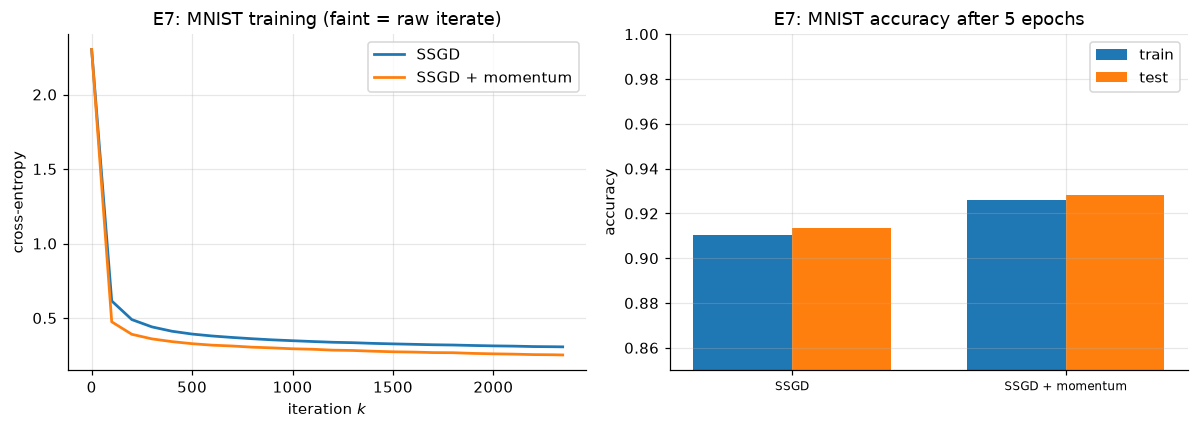

In [9]:
device = get_device(dtype=torch.float32)
mnist = load_mnist()
Xtr_m, ytr_m = mnist["X_train"].to(device), mnist["y_train"].to(device)
Xte_m, yte_m = mnist["X_test"].to(device), mnist["y_test"].to(device)
print(f"MNIST on {device}: train {tuple(Xtr_m.shape)}, test {tuple(Xte_m.shape)}, "
      f"pixels in [{Xtr_m.min():.0f}, {Xtr_m.max():.0f}], labels {ytr_m.dtype}")

ce = lambda m, A, B: torch.nn.functional.cross_entropy(m(A), B)
probe = lambda mm: ce(mm, Xtr_m[:10_000], ytr_m[:10_000])

plt.figure(figsize=(11, 4))
ax = plt.subplot(1, 2, 1)
results = {}
for i, (label, make_opt) in enumerate([
    ("SSGD",            lambda p: SSGD(p, lr=0.5, schedule="inv_sqrt")),
    ("SSGD + momentum", lambda p: SSGDMomentum(p, lr=0.1, beta=0.9, schedule="inv_sqrt")),
]):
    seed_everything(0)
    net = ReLUMLP((784, 128, 10)).to(device)
    hh = train(net, ce, Xtr_m, ytr_m, make_opt(net.parameters()), epochs=5, batch_size=128,
               full_objective=probe, eval_every=100, seed=0)
    results[label] = (evaluate_accuracy(net, Xtr_m, ytr_m), evaluate_accuracy(net, Xte_m, yte_m))
    ax.plot(hh.step, hh.f, color=f"C{i}", alpha=0.35, lw=0.7)
    ax.plot(hh.step, hh.f_best, color=f"C{i}", lw=1.8, label=label)
ax.set(xlabel="iteration $k$", ylabel="cross-entropy", title="E7: MNIST training (faint = raw iterate)")
ax.legend()

ax2 = plt.subplot(1, 2, 2)
labels = list(results)
x = np.arange(len(labels))
ax2.bar(x - 0.18, [results[l][0] for l in labels], 0.36, label="train")
ax2.bar(x + 0.18, [results[l][1] for l in labels], 0.36, label="test")
ax2.set(xticks=x, ylim=(0.85, 1.0), ylabel="accuracy", title="E7: MNIST accuracy after 5 epochs")
ax2.set_xticklabels(labels, fontsize=8)
ax2.legend()
for l in labels:
    print(f"{l:<16} train {results[l][0]:.4f}   test {results[l][1]:.4f}")
plt.tight_layout(); plt.show()

---
## 9. Conclusions

**On the methods**

1. **Correctness is anchored externally.** SSGD reaches scikit-learn's LASSO optimum to within
   $10^{-3}$ with matching coefficients, and recovers the true support of the synthetic problem.
   Autograd's subgradient matches the closed form to $10^{-12}$, and is verified to be a *valid*
   element of the subdifferential at the non-smooth point $w = 0$.
2. **Not a descent method.** $f(w_k)$ rose on **44%** of recorded iterations while the method
   converged perfectly well. Tracking only the raw iterate would make a correct implementation
   look broken.
3. **Step size is the whole game.** A constant step stalls in a noise ball — quadrupling the budget
   changed its optimality gap by less than $10^{-6}$ relative, while both decaying schedules
   improved by 4–18x over the same interval and ended four orders of magnitude closer to
   $f^\star$. Which decay rate wins is problem-dependent (see §4).
4. **Momentum pays off under ill-conditioning**, improving $\kappa(X)=200$ by several orders of
   magnitude, and on MNIST reaching higher accuracy in the same number of epochs. On
   well-conditioned problems its advantage is modest.
5. **Subgradient descent does not produce exact sparsity.** Coefficients approach zero without
   reaching it, so support recovery needs thresholding. Proximal methods (ISTA/FISTA) are the
   right tool when exact zeros matter — a natural extension of this project.

**On the two momentum formulations.** The buffer and difference forms coincide exactly under a
constant step but diverge under a decaying one. Since non-smooth convergence *requires* a decaying
step, which formulation you implement is a real choice here, not a notational one.

**Reproducing this notebook**

```
uv sync --group dev
uv run pytest                # 55 tests
uv run jupyter nbconvert --execute --to notebook --inplace Project.ipynb
```